# 3.3.3 时序分割与变化点检测

## 目标
1. 加载 3.3.2 输出的 JSD 时序数据
2. 使用 ruptures PELT 算法检测战术变化点
3. B-GNN JSD vs EFPI 标签变化率对比
4. 变化点语义分析（战术情境分布）
5. TEI 与 JSD 相关性分析

In [1]:
# 安装 ruptures（在 MORPHenv 虚拟环境中运行）
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ruptures',
                '-i', 'https://pypi.tuna.tsinghua.edu.cn/simple'], check=True)

CompletedProcess(args=['e:\\JerryWu\\Master\\SoccerAnalytics\\G-TAF\\MORPH\\MORPHenv\\Scripts\\python.exe', '-m', 'pip', 'install', 'ruptures', '-i', 'https://pypi.tuna.tsinghua.edu.cn/simple'], returncode=0)

## 1. 环境设置与导入

In [2]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import json
from pathlib import Path

try:
    import ruptures as rpt
    HAS_RUPTURES = True
except ImportError:
    HAS_RUPTURES = False
    print('ruptures 未安装，将使用滑动窗口阈值法替代')
    print('安装命令: pip install ruptures -i https://pypi.tuna.tsinghua.edu.cn/simple')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print(f'ruptures 可用: {HAS_RUPTURES}')

ruptures 可用: True


## 2. 加载数据

In [3]:
base_path = Path(r'E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH')
analysis_dir = base_path / 'data' / 'morph_test' / 'bgnn_analysis'
out_dir = analysis_dir
out_dir.mkdir(parents=True, exist_ok=True)

# 加载 TEI 时序（3.3.2 输出）
tei_df = pl.read_parquet(analysis_dir / 'tei_timeseries_10517.parquet').to_pandas()
tei_df = tei_df.dropna(subset=['time_sec', 'tei', 'period_id']).sort_values('frame_id').reset_index(drop=True)
tei_df['period_id'] = tei_df['period_id'].astype(int)

# 加载 JSD 时序（3.3.2 Cell 20 输出）
jsd_df = pl.read_parquet(analysis_dir / 'jsd_timeseries_10517.parquet').to_pandas()

# 加载 EFPI 结果
efpi_pl = pl.read_parquet(base_path / 'data' / 'morph_test' / 'efpi_baseline' / 'efpi_baseline_results_10517_fullmatch.parquet')
HOME_TEAM_ID = '364'
efpi_home = efpi_pl.filter(pl.col('team_id') == HOME_TEAM_ID).to_pandas().sort_values('frame_id').reset_index(drop=True)

# 合并 JSD + TEI 元数据
ts_meta = tei_df[['frame_id', 'time_sec', 'period_id', 'macro_phase', 'fine_intent', 'top1_formation', 'tei']].drop_duplicates('frame_id')
jsd_merged = jsd_df.merge(ts_meta, on='frame_id', how='left').dropna(subset=['time_sec', 'period_id'])
jsd_merged['period_id'] = jsd_merged['period_id'].astype(int)
jsd_merged = jsd_merged.sort_values('time_sec').reset_index(drop=True)

periods = sorted(jsd_merged['period_id'].unique())
print(f'TEI 数据: {tei_df.shape[0]} 行, period: {sorted(tei_df["period_id"].unique())}')
print(f'JSD 数据: {jsd_merged.shape[0]} 行, period: {periods}')
print(f'EFPI 数据: {efpi_home.shape[0]} 行')

TEI 数据: 549208 行, period: [np.int64(1)]
JSD 数据: 49927 行, period: [np.int64(1)]
EFPI 数据: 1423047 行


## 3. JSD 时序曲线与变化点检测

进球: 6 | 黄牌: 7 | 换人: 13
  P1 22.4min | ARG 1-0 (22:22) Messi
  P1 35.4min | ARG 2-0 (35:21) María
  P2 34.4min | FRA 1-2 (79:24) Mbappé
  P2 36.0min | FRA 2-2 (80:58) Mbappé
  P4 3.0min | ARG 3-2 (107:57) Messi
  P4 12.1min | FRA 3-3 (117:04) Mbappé
Period 1: n=49927, var=0.000008, auto_pen(BIC)=0.000178


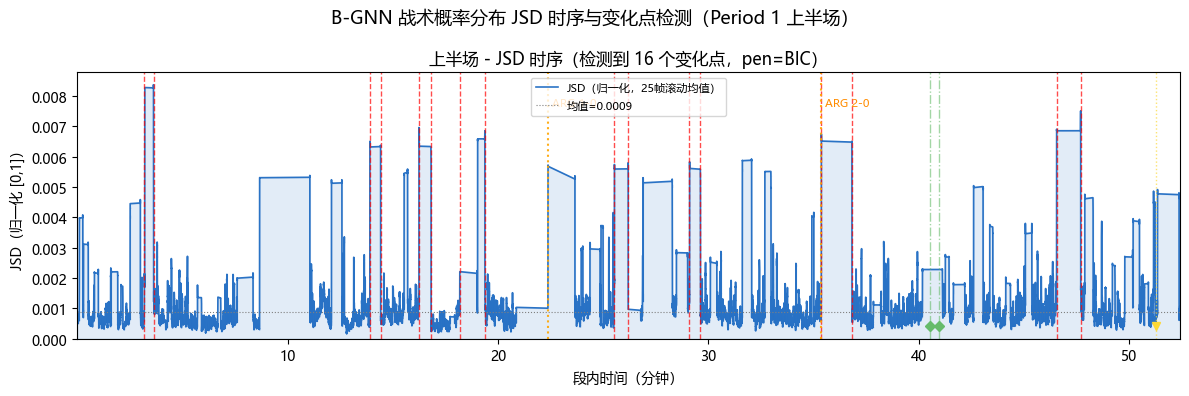

变化点总数: 16, 已保存 changepoints_10517.json


In [4]:
PERIOD_LABELS = {1: '上半场', 2: '下半场', 3: '加时上', 4: '加时下'}
import json as _json_ev

def _load_events(game_id=10517):
    """从 Event Data JSON 动态加载进球/黄牌/换人，period_starts 由踢球事件确定"""
    ev_path = (Path(r'E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData'
                    r'\Gradient Sports  Enhanced 2022 World Cup Dataset\Event Data')
               / f'{game_id}.json')
    period_starts = {1: 0, 2: 2700, 3: 5400, 4: 6300}
    with open(ev_path, 'r', encoding='utf-8') as _f:
        _ev = _json_ev.load(_f)
    goals_raw, yellows, subs = [], [], []
    for e in _ev:
        ge = e.get('gameEvents', {})
        pe = e.get('possessionEvents', {}) or {}
        fo = e.get('fouls', {}) or {}
        period = ge.get('period')
        if period not in period_starts:
            continue
        abs_clock = ge.get('startGameClock') or 0
        ts = abs_clock - period_starts[period]
        fmt = ge.get('startFormattedGameClock', '')
        team = ge.get('teamName', '') or ''
        if pe.get('shotOutcomeType') == 'G' and not (period == 4 and abs_clock > 7300):
            goals_raw.append({'period': period, 'ts': ts, 'fmt': fmt, 'team': team,
                               'player': pe.get('shooterPlayerName', '') or ''})
        if fo.get('finalFoulOutcomeType') == 'Y':
            yellows.append({'period': period, 'ts': ts, 'fmt': fmt, 'team': team,
                            'player': fo.get('finalCulpritPlayerName', '') or ''})
        if ge.get('gameEventType') == 'SUB':
            subs.append({'period': period, 'ts': ts, 'fmt': fmt,
                         'off': ge.get('playerOffName', '') or '',
                         'on':  ge.get('playerOnName',  '') or ''})
    goals_raw.sort(key=lambda x: (x['period'], x['ts']))
    arg, fra, goals = 0, 0, {}
    for g in goals_raw:
        is_arg = 'Argentina' in g['team']
        arg += is_arg; fra += (not is_arg)
        surname = g['player'].split()[-1] if g['player'] else '?'
        label = (f"ARG {arg}-{fra} ({g['fmt']}) {surname}" if is_arg
                 else f"FRA {fra}-{arg} ({g['fmt']}) {surname}")
        goals[label] = (g['period'], g['ts'])
    return goals, yellows, subs

GOALS, YELLOW_CARDS, SUBSTITUTIONS = _load_events(10517)
print(f'进球: {len(GOALS)} | 黄牌: {len(YELLOW_CARDS)} | 换人: {len(SUBSTITUTIONS)}')
for _lbl, (_pid, _ts) in GOALS.items():
    print(f'  P{_pid} {_ts/60:.1f}min | {_lbl}')
NUM_CLASSES = 65  # B-GNN 类别数，JSD 上界 = log2(65) ≈ 6.02 bits

def detect_changepoints(signal_1d, pen, min_size=50, jump=5):
    """l2 模型：pen 需与信号方差同量纲，由调用方自适应传入"""
    if HAS_RUPTURES:
        algo = rpt.Pelt(model='l2', min_size=min_size, jump=jump).fit(signal_1d.reshape(-1, 1))
        bkps = algo.predict(pen=pen)
        return [b - 1 for b in bkps if b < len(signal_1d)]
    else:
        smoothed = pd.Series(signal_1d).rolling(min_size, center=True, min_periods=1).mean()
        threshold = smoothed.mean() + 2.0 * smoothed.std()
        changes, in_region = [], False
        for i, v in enumerate(smoothed > threshold):
            if v and not in_region:
                changes.append(i)
                in_region = True
            elif not v:
                in_region = False
        return changes

all_changepoints = {}
fig, axes = plt.subplots(len(periods), 1, figsize=(12, 4 * len(periods)), squeeze=False)

for row_i, pid in enumerate(periods):
    ax = axes[row_i, 0]
    sub = jsd_merged[jsd_merged['period_id'] == pid].sort_values('time_sec').reset_index(drop=True)
    if len(sub) < 50:
        ax.set_title(f"{PERIOD_LABELS.get(pid, f'P{pid}')} - 数据不足")
        continue

    # 归一化到 [0,1]：除以 log2(NUM_CLASSES)
    jsd_norm = np.clip(sub['jsd'].values / np.log2(NUM_CLASSES), 0, 1)
    smooth = pd.Series(jsd_norm).rolling(25, center=True, min_periods=1).mean()
    t_min, t_max = sub['time_sec'].min(), sub['time_sec'].max()

    # 自适应 pen：BIC-like 公式，pen = 2 * sig_var * log(n)
    sig_var = np.var(jsd_norm)
    n = len(jsd_norm)
    auto_pen = max(2 * sig_var * np.log(n), 1e-8)
    print(f'Period {pid}: n={n}, var={sig_var:.6f}, auto_pen(BIC)={auto_pen:.6f}')

    ax.plot(sub['time_sec'] / 60, smooth, lw=1.2, color='#1565C0', alpha=0.9, label='JSD（归一化，25帧滚动均值）')
    ax.fill_between(sub['time_sec'] / 60, smooth, alpha=0.12, color='#1565C0')

    cp_indices = detect_changepoints(jsd_norm, pen=auto_pen)
    cp_records = []
    for idx in cp_indices:
        if idx < len(sub):
            r = sub.iloc[idx]
            ax.axvline(r['time_sec'] / 60, color='red', lw=1, ls='--', alpha=0.7)
            cp_records.append({
                'frame_id': int(r['frame_id']),
                'time_sec': float(r['time_sec']),
                'time_min': float(r['time_sec'] / 60),
                'period_id': int(pid),
                'macro_phase': str(r.get('macro_phase', '')),
                'fine_intent': str(r.get('fine_intent', '')),
                'top1_formation': str(r.get('top1_formation', '')),
                'jsd': float(jsd_norm[idx]),
                'tei': float(r['tei']) if 'tei' in r.index else float('nan'),
            })
    all_changepoints[int(pid)] = cp_records

    for label, (gpid, gt) in GOALS.items():
        if gpid == pid and t_min <= gt <= t_max:
            ax.axvline(gt / 60, color='orange', lw=1.5, ls=':', alpha=0.9)
            ax.text(gt / 60 + 0.2, smooth.max() * 0.95, label.split('(')[0].strip(),
                    fontsize=8, color='darkorange', va='top')
    # 黄牌（金黄竖线 + 倒三角）
    for yc in YELLOW_CARDS:
        if yc['period'] == pid and t_min <= yc['ts'] <= t_max:
            ax.axvline(yc['ts'] / 60, color='#FDD835', lw=1, ls=':', alpha=0.7)
            ax.plot(yc['ts'] / 60, smooth.max() * 0.05, marker='v',
                    color='#FDD835', markersize=6, zorder=5)
    # 换人（绿色竖线 + 菱形）
    for sb in SUBSTITUTIONS:
        if sb['period'] == pid and t_min <= sb['ts'] <= t_max:
            ax.axvline(sb['ts'] / 60, color='#66BB6A', lw=1, ls='-.', alpha=0.6)
            ax.plot(sb['ts'] / 60, smooth.max() * 0.05, marker='D',
                    color='#66BB6A', markersize=5, zorder=5)

    ax.axhline(smooth.mean(), color='gray', lw=0.8, ls=':', label=f'均值={smooth.mean():.4f}')
    ax.set_xlim(t_min / 60, t_max / 60)
    ax.set_ylim(0, None)
    ax.set_xlabel('段内时间（分钟）')
    ax.set_ylabel('JSD（归一化 [0,1]）')
    ax.set_title(f"{PERIOD_LABELS.get(pid, f'P{pid}')} - JSD 时序（检测到 {len(cp_records)} 个变化点，pen=BIC）")
    ax.legend(fontsize=8)

plt.suptitle('B-GNN 战术概率分布 JSD 时序与变化点检测（Period 1 上半场）', fontsize=13)
plt.tight_layout()
fig.savefig(out_dir / 'jsd_changepoints_10517.png', dpi=150, bbox_inches='tight')
plt.show()

flat_cps = [cp for cps in all_changepoints.values() for cp in cps]
with open(out_dir / 'changepoints_10517.json', 'w', encoding='utf-8') as f:
    json.dump(flat_cps, f, ensure_ascii=False, indent=2)
print(f'变化点总数: {len(flat_cps)}, 已保存 changepoints_10517.json')

## 3.5 GM-TEI 时序与变化点联合可视化

将 `b1_window_distributions.parquet` 的 GM-TEI_AB / GM-TEI_CB 时序与 PELT 变化点、进球/黄牌/换人事件叠加展示，验证 GM-TEI 在战术转变时刻的响应能力。

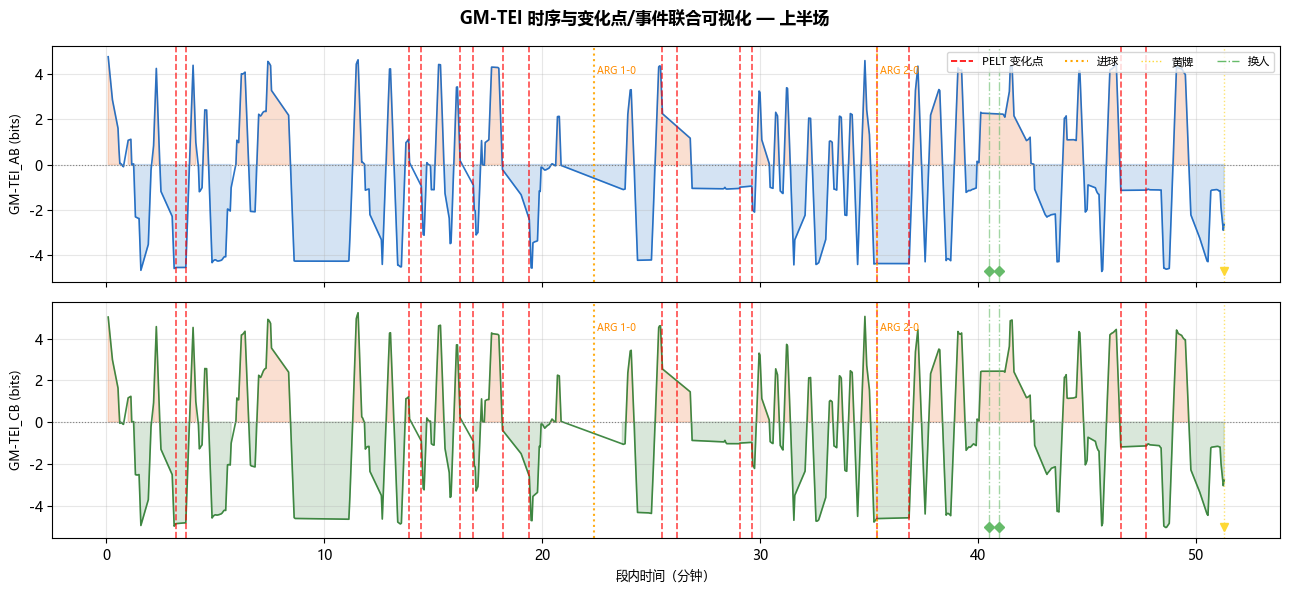

已保存 gm_tei_cp_events_1_10517.png


In [5]:
# 加载窗口级 GM-TEI
b1_path_33 = (base_path / 'Step3_Probabilistic_Identification'
              / '3.2_Probabilistic_Model' / 'Test' / 'b1_window_distributions.parquet')
b1_w = pd.read_parquet(b1_path_33)
ts_meta_33 = jsd_merged[['frame_id','time_sec','period_id']].drop_duplicates('frame_id')
b1_w = b1_w.merge(ts_meta_33.rename(columns={'frame_id':'center_fid'}),
                  on='center_fid', how='left').dropna(subset=['time_sec'])
b1_w['period_id'] = b1_w['period_id'].astype(int)

if not all(c in b1_w.columns for c in ['gm_tei_ab','gm_tei_cb']):
    print('[SKIP] b1_window_distributions.parquet 缺少 GM-TEI 列')
else:
    WROLL_33 = 8
    for pid in periods:
        sub_b = b1_w[b1_w['period_id']==pid].sort_values('time_sec').reset_index(drop=True)
        if len(sub_b) < 5:
            continue
        t = sub_b['time_sec'] / 60
        ab_s = sub_b['gm_tei_ab'].rolling(WROLL_33, center=True, min_periods=1).mean()
        cb_s = sub_b['gm_tei_cb'].rolling(WROLL_33, center=True, min_periods=1).mean()
        t_min_p = t.min(); t_max_p = t.max()

        fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

        for ax, vals, color, ylabel in [
            (axes[0], ab_s, '#1565C0', 'GM-TEI_AB'),
            (axes[1], cb_s, '#2E7D32', 'GM-TEI_CB'),
        ]:
            ax.plot(t, vals, lw=1.2, color=color, alpha=0.9)
            ax.fill_between(t, vals, 0, where=vals>=0, alpha=0.18, color='#E65100')
            ax.fill_between(t, vals, 0, where=vals<0,  alpha=0.18, color=color)
            ax.axhline(0, color='gray', lw=0.8, ls=':')
            ax.set_ylabel(ylabel + ' (bits)', fontsize=9)
            ax.grid(True, alpha=0.3)

            # 变化点（红虚线）
            cp_list = all_changepoints.get(pid, [])
            for cp in cp_list:
                ax.axvline(cp['time_sec']/60, color='red', lw=1.2, ls='--', alpha=0.7)

            # 进球（橙色点线）
            for lbl, (gpid, gt) in GOALS.items():
                if gpid == pid and t_min_p <= gt/60 <= t_max_p:
                    ax.axvline(gt/60, color='orange', lw=1.5, ls=':', alpha=0.9)
                    ax.text(gt/60+0.15, vals.max()*0.92,
                            lbl.split('(')[0].strip(), fontsize=7, color='darkorange', va='top')

            # 黄牌（金黄）
            for yc in YELLOW_CARDS:
                if yc['period']==pid and t_min_p <= yc['ts']/60 <= t_max_p:
                    ax.axvline(yc['ts']/60, color='#FDD835', lw=1, ls=':', alpha=0.7)
                    ax.plot(yc['ts']/60, vals.min(), marker='v',
                            color='#FDD835', markersize=6, zorder=5)

            # 换人（绿色）
            for sb in SUBSTITUTIONS:
                if sb['period']==pid and t_min_p <= sb['ts']/60 <= t_max_p:
                    ax.axvline(sb['ts']/60, color='#66BB6A', lw=1, ls='-.', alpha=0.6)
                    ax.plot(sb['ts']/60, vals.min(), marker='D',
                            color='#66BB6A', markersize=5, zorder=5)

        axes[1].set_xlabel('段内时间（分钟）', fontsize=9)
        from matplotlib.lines import Line2D
        legend_handles = [
            Line2D([0],[0], color='red',    lw=1.2, ls='--', label='PELT 变化点'),
            Line2D([0],[0], color='orange', lw=1.5, ls=':',  label='进球'),
            Line2D([0],[0], color='#FDD835',lw=1,   ls=':',  label='黄牌'),
            Line2D([0],[0], color='#66BB6A',lw=1,   ls='-.', label='换人'),
        ]
        axes[0].legend(handles=legend_handles, fontsize=8, ncol=4, loc='upper right')
        fig.suptitle(f'GM-TEI 时序与变化点/事件联合可视化 — {PERIOD_LABELS.get(pid,f"P{pid}")}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        fig.savefig(out_dir / f'gm_tei_cp_events_{pid}_10517.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'已保存 gm_tei_cp_events_{pid}_10517.png')

## 4. B-GNN JSD vs EFPI 标签变化率对比

Period 1: JSD帧=49927, EFPI原始行=549208, EFPI去重帧=49928, 窗口=25


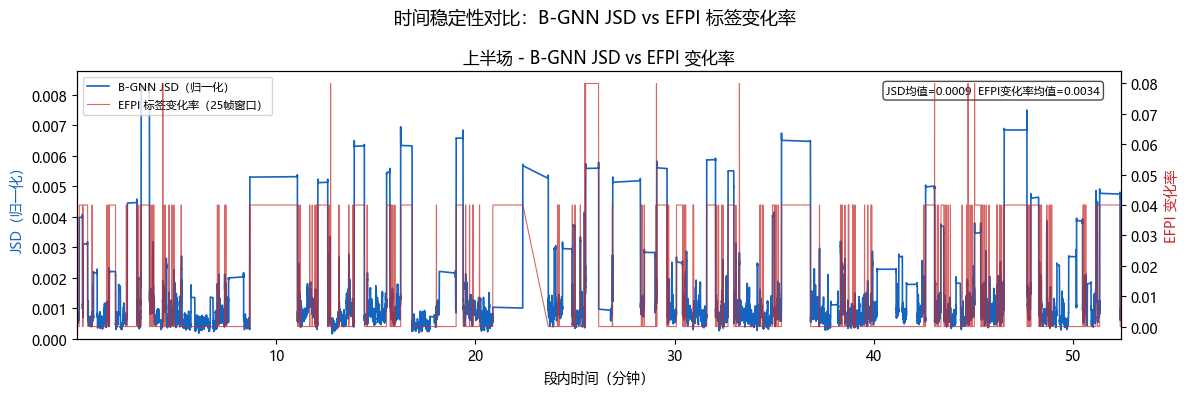

In [6]:
# efpi_home 自带 period_id，merge 时只取 time_sec 避免列名冲突
efpi_ts = efpi_home.merge(ts_meta[['frame_id', 'time_sec']], on='frame_id', how='left')
efpi_ts = efpi_ts.dropna(subset=['time_sec', 'period_id']).sort_values('time_sec').reset_index(drop=True)
efpi_ts['period_id'] = efpi_ts['period_id'].astype(int)

fig, axes = plt.subplots(len(periods), 1, figsize=(12, 4 * len(periods)), squeeze=False)

for row_i, pid in enumerate(periods):
    ax = axes[row_i, 0]
    sub_jsd = jsd_merged[jsd_merged['period_id'] == pid].sort_values('time_sec').reset_index(drop=True)
    sub_efpi = efpi_ts[efpi_ts['period_id'] == pid].sort_values('time_sec').reset_index(drop=True)
    if len(sub_jsd) < 50 or len(sub_efpi) < 2:
        ax.set_title(f"{PERIOD_LABELS.get(pid, f'P{pid}')} - 数据不足")
        continue

    jsd_norm = np.clip(sub_jsd['jsd'].values / np.log2(NUM_CLASSES), 0, 1)
    jsd_smooth = pd.Series(jsd_norm).rolling(25, center=True, min_periods=1).mean()

    # EFPI 每帧含多行球员记录，需先按 frame_id 去重得到真实帧序列
    efpi_frames = sub_efpi.drop_duplicates('frame_id').sort_values('time_sec').reset_index(drop=True)
    efpi_chg = (efpi_frames['formation'].values[1:] != efpi_frames['formation'].values[:-1]).astype(float)
    # 固定窗口 25 帧（与 JSD 平滑窗口一致），保留脉冲细节
    efpi_smooth = pd.Series(efpi_chg).rolling(25, center=True, min_periods=1).mean()
    print(f'Period {pid}: JSD帧={len(sub_jsd)}, EFPI原始行={len(sub_efpi)}, EFPI去重帧={len(efpi_frames)}, 窗口=25')

    t_min = sub_jsd['time_sec'].min()
    t_max = sub_jsd['time_sec'].max()
    ax2 = ax.twinx()
    l1, = ax.plot(sub_jsd['time_sec'] / 60, jsd_smooth, lw=1.2, color='#1565C0', label='B-GNN JSD（归一化）')
    l2, = ax2.plot(efpi_frames['time_sec'].values[1:] / 60, efpi_smooth, lw=0.8, color='#C62828', alpha=0.7,
                   label='EFPI 标签变化率（25帧窗口）')
    ax.set_xlim(t_min / 60, t_max / 60)
    ax.set_ylim(0, None)
    ax.set_xlabel('段内时间（分钟）')
    ax.set_ylabel('JSD（归一化）', color='#1565C0')
    ax2.set_ylabel('EFPI 变化率', color='#C62828')
    ax.set_title(f"{PERIOD_LABELS.get(pid, f'P{pid}')} - B-GNN JSD vs EFPI 变化率")
    ax.legend(handles=[l1, l2], fontsize=8, loc='upper left')
    ax.text(0.98, 0.95, f'JSD均值={jsd_smooth.mean():.4f}  EFPI变化率均值={efpi_smooth.mean():.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('时间稳定性对比：B-GNN JSD vs EFPI 标签变化率', fontsize=13)
plt.tight_layout()
fig.savefig(out_dir / 'jsd_vs_efpi_10517.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 变化点语义分析

变化点总数: 16
 time_min                 macro_phase    fine_intent top1_formation      jsd      tei
 3.193763     In-Possession Open Play       BUILD_UP           4321 0.000910 4.183392
 3.630867     In-Possession Open Play       BUILD_UP            352 0.000747 3.755486
13.906698     In-Possession Open Play ATTACKING_PLAY           4132 0.000180 3.489332
14.431668 Out-of-Possession Open Play      MID_BLOCK            532 0.000831 3.012116
16.225684     In-Possession Open Play ATTACKING_PLAY            343 0.000634 1.656037
16.815718 Out-of-Possession Open Play      MID_BLOCK            442 0.139079 1.571688
18.189870 Out-of-Possession Open Play      LOW_BLOCK            352 0.000737 3.637591
19.373832     In-Possession Open Play       BUILD_UP       3511flat 0.001573 3.184156
25.516085 Out-of-Possession Open Play      MID_BLOCK            433 0.000316 3.974027
26.186200 Out-of-Possession Open Play      LOW_BLOCK          32122 0.000512 3.608327
29.087991     In-Possession Open Play ATTACK

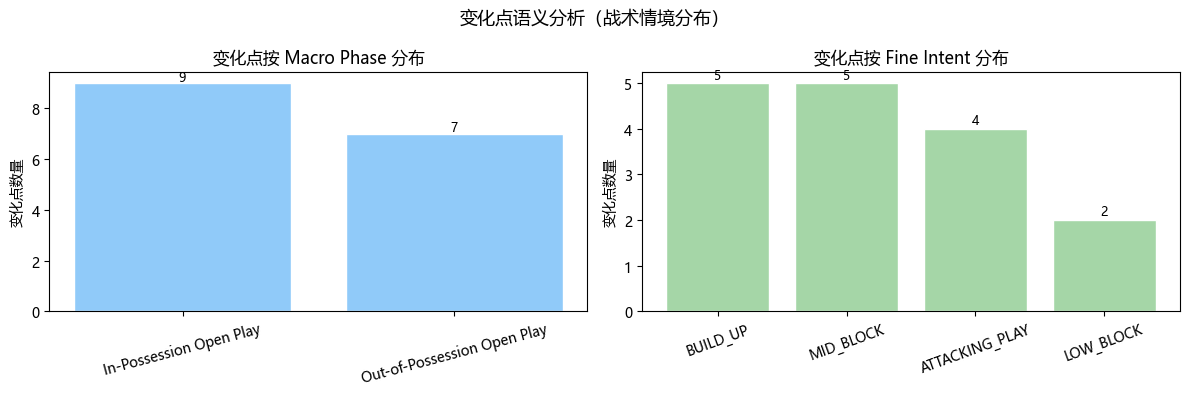

变化点 Top-1 阵型分布:
top1_formation
352         2
343         2
4141        2
4132        1
4321        1
532         1
442         1
433         1
3511flat    1
32122       1
Name: count, dtype: int64
变化点 TEI 均值=3.027 bits，中位数=3.336 bits


In [7]:
if len(flat_cps) == 0:
    print('无变化点，跳过语义分析')
else:
    cp_df = pd.DataFrame(flat_cps)
    print(f'变化点总数: {len(cp_df)}')
    cols = ['time_min', 'macro_phase', 'fine_intent', 'top1_formation', 'jsd', 'tei']
    print(cp_df[[c for c in cols if c in cp_df.columns]].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    macro_counts = cp_df['macro_phase'].value_counts()
    axes[0].bar(macro_counts.index, macro_counts.values, color='#90CAF9', edgecolor='white')
    axes[0].set_title('变化点按 Macro Phase 分布')
    axes[0].set_ylabel('变化点数量')
    axes[0].tick_params(axis='x', rotation=15)
    for i, v in enumerate(macro_counts.values):
        axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=9)

    fine_counts = cp_df['fine_intent'].value_counts()
    axes[1].bar(fine_counts.index, fine_counts.values, color='#A5D6A7', edgecolor='white')
    axes[1].set_title('变化点按 Fine Intent 分布')
    axes[1].set_ylabel('变化点数量')
    axes[1].tick_params(axis='x', rotation=20)
    for i, v in enumerate(fine_counts.values):
        axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=9)

    plt.suptitle('变化点语义分析（战术情境分布）', fontsize=13)
    plt.tight_layout()
    fig.savefig(out_dir / 'changepoint_analysis_10517.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('变化点 Top-1 阵型分布:')
    print(cp_df['top1_formation'].value_counts().head(10))
    if 'tei' in cp_df.columns:
        print(f'变化点 TEI 均值={cp_df["tei"].mean():.3f} bits，中位数={cp_df["tei"].median():.3f} bits')

## 6. GM-TEI 与变化点几何特征分析

以 `b1_window_distributions.parquet` 的窗口级数据为基础，对每个变化点找到最近窗口，分析变化点处的 GM-TEI / 几何特征，与非变化点窗口对比，验证 GM-TEI 在战术转变时刻的响应能力。

变化点窗口: 16  非变化点窗口: 646

指标                    变化点均值         非变化点均值           p值
--------------------------------------------------------
gm_tei_ab            4.4228         4.3941     5.57e-01  
gm_tei_cb            4.6575         4.5746     2.25e-01  
spread_mean         13.3172        15.3428     6.51e-04 *
lr_mean              0.1267         0.1313     8.12e-01  
rect_mean            0.6523         0.6510     7.57e-01  


C:\Users\11254\AppData\Local\Temp\ipykernel_15236\2970119511.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([b1_non['gm_tei_ab'].abs(), b1_cp['gm_tei_ab'].abs(),


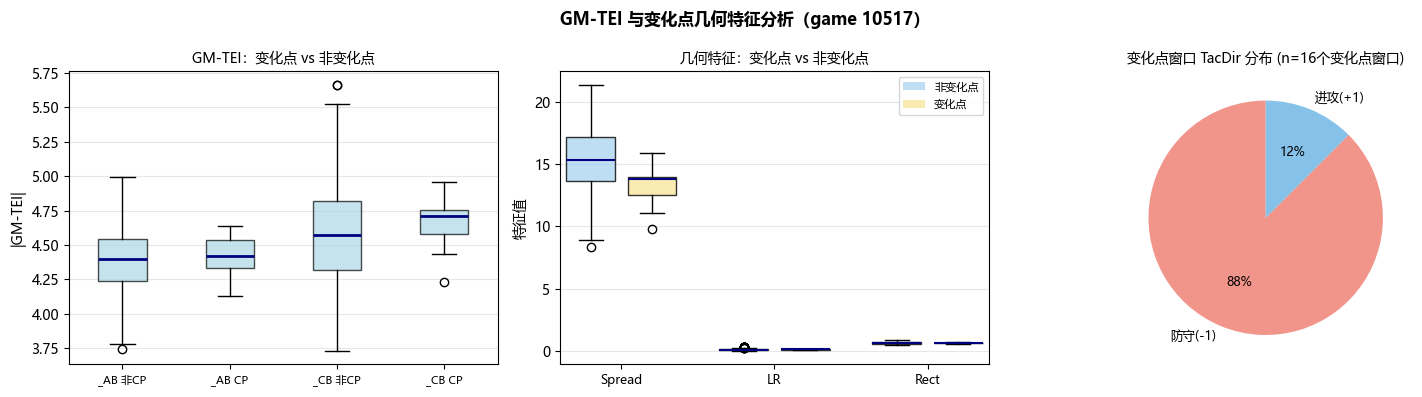

已保存 gm_tei_changepoints_10517.png


In [8]:
from pathlib import Path
from scipy.stats import mannwhitneyu

b1_path = (Path(r'E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH')
           / 'Step3_Probabilistic_Identification' / '3.2_Probabilistic_Model'
           / 'Test' / 'b1_window_distributions.parquet')
b1_win = pd.read_parquet(b1_path)

if len(flat_cps) == 0 or not all(c in b1_win.columns for c in ['gm_tei_ab', 'gm_tei_cb', 'tac_dir']):
    print('[SKIP] 无变化点或 b1_window_distributions.parquet 缺少 GM-TEI 列')
else:
    # 为每个变化点找最近窗口
    cp_fids = [cp['frame_id'] for cp in flat_cps]
    b1_win = b1_win.copy()
    b1_win['is_cp'] = False
    for fid in cp_fids:
        idx = (b1_win['center_fid'] - fid).abs().idxmin()
        b1_win.at[idx, 'is_cp'] = True

    cp_mask = b1_win['is_cp']
    b1_cp  = b1_win[cp_mask]
    b1_non = b1_win[~cp_mask]

    geom_cols = ['gm_tei_ab', 'gm_tei_cb', 'spread_mean', 'lr_mean', 'rect_mean']
    print(f'变化点窗口: {len(b1_cp)}  非变化点窗口: {len(b1_non)}')
    print()
    print(f"{'指标':<14} {'变化点均值':>12} {'非变化点均值':>14} {'p值':>12}")
    print('-' * 56)
    for col in geom_cols:
        u, p = mannwhitneyu(b1_cp[col].abs(), b1_non[col].abs(), alternative='two-sided')
        sig = '*' if p < 0.05 else ' '
        print(f"{col:<14} {b1_cp[col].abs().mean():>12.4f} {b1_non[col].abs().mean():>14.4f} {p:>12.2e} {sig}")

    # 可视化：3列图
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 左：GM-TEI_AB / GM-TEI_CB 箱线图（取绝对值）
    axes[0].boxplot([b1_non['gm_tei_ab'].abs(), b1_cp['gm_tei_ab'].abs(),
                     b1_non['gm_tei_cb'].abs(), b1_cp['gm_tei_cb'].abs()],
                    labels=['_AB 非CP', '_AB CP', '_CB 非CP', '_CB CP'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='navy', lw=2))
    axes[0].set_ylabel('|GM-TEI|', fontsize=10)
    axes[0].set_title('GM-TEI：变化点 vs 非变化点', fontsize=10)
    axes[0].tick_params(axis='x', labelsize=8)
    axes[0].grid(True, axis='y', alpha=0.3)

    # 中：几何特征（Spread / LR / Rect）箱线图
    for j, col in enumerate(['spread_mean', 'lr_mean', 'rect_mean']):
        bp = axes[1].boxplot([b1_non[col], b1_cp[col]],
                             positions=[j*2.5, j*2.5+1], widths=0.8,
                             patch_artist=True,
                             medianprops=dict(color='navy', lw=1.5))
        for patch, color in zip(bp['boxes'], ['#AED6F1', '#F9E79F']):
            patch.set_facecolor(color); patch.set_alpha(0.8)
    axes[1].set_xticks([0.5, 3.0, 5.5])
    axes[1].set_xticklabels(['Spread', 'LR', 'Rect'], fontsize=9)
    axes[1].set_ylabel('特征值', fontsize=10)
    axes[1].set_title('几何特征：变化点 vs 非变化点', fontsize=10)
    axes[1].grid(True, axis='y', alpha=0.3)
    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(facecolor='#AED6F1', alpha=0.8, label='非变化点'),
                             Patch(facecolor='#F9E79F', alpha=0.8, label='变化点')], fontsize=8)

    # 右：TacDir 在变化点窗口的分布
    tac_counts = b1_cp['tac_dir'].value_counts().sort_index()
    tac_labels_map = {1.0: '进攻(+1)', 0.0: '中性(0)', -1.0: '防守(-1)'}
    colors_map = {1.0: '#85C1E9', 0.0: '#F0E68C', -1.0: '#F1948A'}
    pie_labels = [tac_labels_map.get(k, str(k)) for k in tac_counts.index]
    pie_colors = [colors_map.get(k, 'gray') for k in tac_counts.index]
    axes[2].pie(tac_counts.values, labels=pie_labels, colors=pie_colors,
                autopct='%1.0f%%', startangle=90, textprops={'fontsize': 9})
    axes[2].set_title(f'变化点窗口 TacDir 分布 (n={len(b1_cp)}个变化点窗口)', fontsize=10)

    plt.suptitle('GM-TEI 与变化点几何特征分析（game 10517）', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig.savefig(out_dir / 'gm_tei_changepoints_10517.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('已保存 gm_tei_changepoints_10517.png')

## 7. 置信区间宽度与战术转变相关性

**假设**：战术转变窗口（变化点附近 ±HALF_WIN 个窗口）的 Dirichlet CI 宽度显著大于稳定期。

- CI 宽度 = 1.96 × sqrt(probvar_k 均値)，来自 `b1_window_distributions.parquet`
- 变化点附近：以每个 PELT 变化点为中心，前后各 `HALF_WIN=3` 个窗口标记为“转变期”
- 检验：Mann-Whitney U（单侧，转变期 > 稳定期）


转变期窗口数: 65  稳定期窗口数: 597
转变期 CI 半宽均値: 0.033523  中位数: 0.033759
稳定期 CI 半宽均値: 0.032713  中位数: 0.032710
Mann-Whitney U=27382, p=2.4870e-08
结论: ✅ 显著 (p<0.05)


C:\Users\11254\AppData\Local\Temp\ipykernel_15236\1120749510.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(
C:\Users\11254\AppData\Local\Temp\ipykernel_15236\1120749510.py:81: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\11254\AppData\Local\Temp\ipykernel_15236\1120749510.py:84: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  fig.savefig(out_dir_ci / 'ci_vs_changepoints_10517.png', dpi=150, bbox_inches='tight')
e:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH\MORPHenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


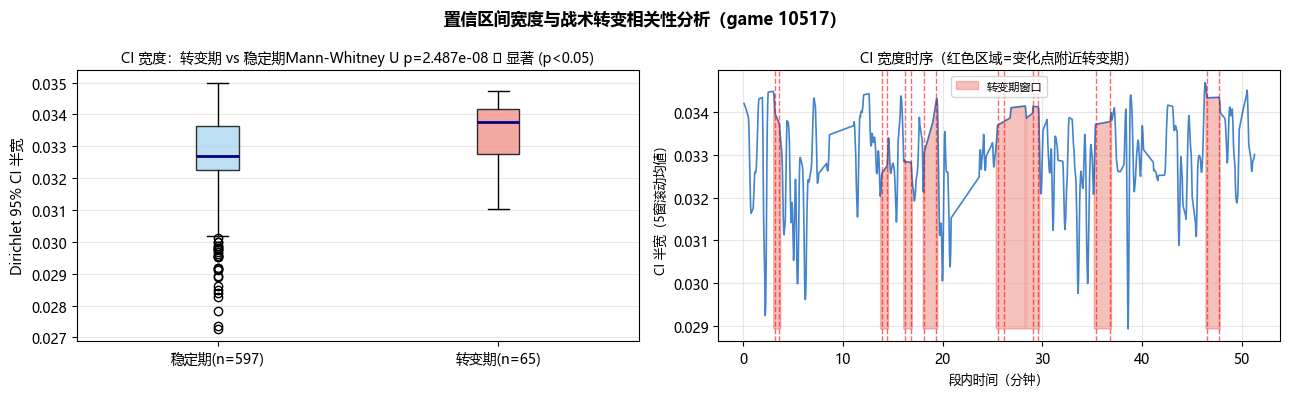

已保存 ci_vs_changepoints_10517.png


In [10]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HALF_WIN = 3   # 变化点前后各 3 个窗口（约 ±22.5s，STRIDE=75帧@25fps）

try:
    _ = b1_win.shape
except NameError:
    b1_win = pd.read_parquet(
        Path(r'E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH')
        / 'Step3_Probabilistic_Identification' / '3.2_Probabilistic_Model'
        / 'Test' / 'b1_window_distributions.parquet')

probvar_cols = [c for c in b1_win.columns if c.startswith('probvar_')]
if not probvar_cols:
    print('[SKIP] b1_window_distributions.parquet 缺少 probvar_* 列')
elif len(flat_cps) == 0:
    print('[SKIP] 无变化点，跳过 CI 宽度检验')
else:
    b1_ci = b1_win.copy()
    b1_ci['ci_half'] = (
        b1_ci[probvar_cols].clip(lower=0).pow(0.5).mean(axis=1) * 1.96
    )
    cp_fids_ci = [cp['frame_id'] for cp in flat_cps]
    b1_ci = b1_ci.sort_values('center_fid').reset_index(drop=True)
    b1_ci['is_transition'] = False
    for fid in cp_fids_ci:
        center_idx = (b1_ci['center_fid'] - fid).abs().idxmin()
        lo = max(0, center_idx - HALF_WIN)
        hi = min(len(b1_ci) - 1, center_idx + HALF_WIN)
        b1_ci.loc[lo:hi, 'is_transition'] = True

    ci_trans  = b1_ci[b1_ci['is_transition']]['ci_half'].dropna()
    ci_stable = b1_ci[~b1_ci['is_transition']]['ci_half'].dropna()

    stat, p = mannwhitneyu(ci_trans, ci_stable, alternative='greater')
    print(f'转变期窗口数: {len(ci_trans)}  稳定期窗口数: {len(ci_stable)}')
    print(f'转变期 CI 半宽均値: {ci_trans.mean():.6f}  中位数: {ci_trans.median():.6f}')
    print(f'稳定期 CI 半宽均値: {ci_stable.mean():.6f}  中位数: {ci_stable.median():.6f}')
    print(f'Mann-Whitney U={stat:.0f}, p={p:.4e}')
    sig = '✅ 显著 (p<0.05)' if p < 0.05 else '❌ 不显著'
    print(f'结论: {sig}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    bp = axes[0].boxplot(
        [ci_stable.values, ci_trans.values],
        labels=[f'稳定期(n={len(ci_stable)})', f'转变期(n={len(ci_trans)})'],
        patch_artist=True, medianprops=dict(color='navy', lw=2)
    )
    bp['boxes'][0].set_facecolor('#AED6F1'); bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor('#F1948A'); bp['boxes'][1].set_alpha(0.8)
    axes[0].set_ylabel('Dirichlet 95% CI 半宽', fontsize=10)
    axes[0].set_title(f'CI 宽度：转变期 vs 稳定期Mann-Whitney U p={p:.3e} {sig}', fontsize=10)
    axes[0].grid(True, axis='y', alpha=0.3)

    ts_meta_ci = jsd_merged[['frame_id','time_sec','period_id']].drop_duplicates('frame_id')
    b1_ci_t = b1_ci.merge(ts_meta_ci.rename(columns={'frame_id':'center_fid'}),
                           on='center_fid', how='left').dropna(subset=['time_sec'])
    b1_ci_t['period_id'] = b1_ci_t['period_id'].astype(int)
    for pid in sorted(b1_ci_t['period_id'].unique()):
        sub = b1_ci_t[b1_ci_t['period_id']==pid].sort_values('time_sec')
        t = sub['time_sec'] / 60
        ci_s = sub['ci_half'].rolling(5, center=True, min_periods=1).mean()
        axes[1].plot(t, ci_s, lw=1.2, color='#1565C0', alpha=0.8)
        trans_mask = sub['is_transition'].values
        axes[1].fill_between(t, ci_s, ci_s.min(), where=trans_mask,
                              alpha=0.35, color='#E74C3C', label='转变期窗口')
        for cp in flat_cps:
            if cp['period_id'] == pid:
                axes[1].axvline(cp['time_sec']/60, color='red', lw=1, ls='--', alpha=0.6)
    axes[1].set_xlabel('段内时间（分钟）', fontsize=9)
    axes[1].set_ylabel('CI 半宽（5窗滚动均値）', fontsize=9)
    axes[1].set_title('CI 宽度时序（红色区域=变化点附近转变期）', fontsize=10)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    plt.suptitle('置信区间宽度与战术转变相关性分析（game 10517）',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_dir_ci = (Path(r'E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH')
                  / 'data' / 'morph_test' / 'bgnn_analysis')
    fig.savefig(out_dir_ci / 'ci_vs_changepoints_10517.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('已保存 ci_vs_changepoints_10517.png')


## 6. TEI 与 JSD 相关性分析

Pearson r=0.0810, p=2.3033e-73
Spearman r=0.2114, p=0.0000e+00
JSD 归一化后: mean=0.000889, std=0.002867, range=[0.000019, 0.139493]
注：TEI 衡量单帧内部不确定性，JSD 衡量相邻帧间分布变化，两者弱相关属正常现象。
[诊断] JSD std=0.002867 极小，信号近似常数，相关性分析受限；散点图改用 hexbin 密度图。


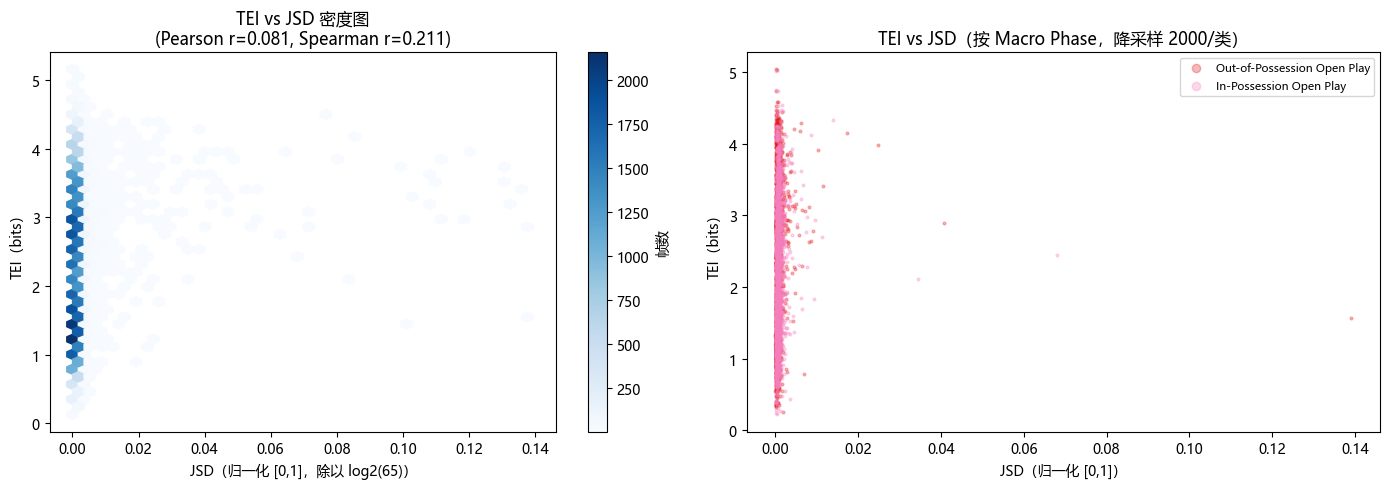

In [11]:
df_corr = jsd_merged.dropna(subset=['jsd', 'tei', 'macro_phase'])
# 归一化到 [0,1]：除以 log2(NUM_CLASSES=65)
jsd_norm_all = np.clip(df_corr['jsd'].values / np.log2(NUM_CLASSES), 0, 1)
tei_vals = df_corr['tei'].values

r_pearson, p_pearson = pearsonr(jsd_norm_all, tei_vals)
r_spearman, p_spearman = spearmanr(jsd_norm_all, tei_vals)
print(f'Pearson r={r_pearson:.4f}, p={p_pearson:.4e}')
print(f'Spearman r={r_spearman:.4f}, p={p_spearman:.4e}')
jsd_std = np.std(jsd_norm_all)
print(f'JSD 归一化后: mean={np.mean(jsd_norm_all):.6f}, std={jsd_std:.6f}, range=[{jsd_norm_all.min():.6f}, {jsd_norm_all.max():.6f}]')
print('注：TEI 衡量单帧内部不确定性，JSD 衡量相邻帧间分布变化，两者弱相关属正常现象。')
if jsd_std < 0.01:
    print(f'[诊断] JSD std={jsd_std:.6f} 极小，信号近似常数，相关性分析受限；散点图改用 hexbin 密度图。')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：hexbin 密度图（替代散点，避免点重叠导致退化）
hb = axes[0].hexbin(jsd_norm_all, tei_vals, gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=axes[0], label='帧数')
axes[0].set_xlabel('JSD（归一化 [0,1]，除以 log2(65)）')
axes[0].set_ylabel('TEI（bits）')
axes[0].set_title(f'TEI vs JSD 密度图\n(Pearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f})')

# 右图：按 macro_phase 分组的散点（降采样至 2000 点避免过密）
phases = df_corr['macro_phase'].unique()
colors = plt.cm.Set1(np.linspace(0, 0.8, len(phases)))
rng = np.random.default_rng(42)
for phase, color in zip(phases, colors):
    mask = (df_corr['macro_phase'] == phase).values
    idx = np.where(mask)[0]
    if len(idx) > 2000:
        idx = rng.choice(idx, 2000, replace=False)
    axes[1].scatter(jsd_norm_all[idx], tei_vals[idx], c=[color], alpha=0.3, s=4, label=phase)
axes[1].set_xlabel('JSD（归一化 [0,1]）')
axes[1].set_ylabel('TEI（bits）')
axes[1].set_title('TEI vs JSD（按 Macro Phase，降采样 2000/类）')
axes[1].legend(fontsize=8, markerscale=3)

plt.tight_layout()
fig.savefig(out_dir / 'tei_jsd_correlation_10517.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 总结

### 输出文件
```
data/morph_test/bgnn_analysis/
├── jsd_changepoints_10517.png          # JSD 时序 + 变化点标注
├── changepoints_10517.json             # 变化点列表（帧ID、时间、战术情境）
├── jsd_vs_efpi_10517.png               # B-GNN JSD vs EFPI 变化率对比
├── changepoint_analysis_10517.png      # 变化点语义分析（战术情境分布）
├── tei_jsd_correlation_10517.png       # TEI 与 JSD 相关性散点图
├── gm_tei_changepoints_10517.png       # GM-TEI / 几何特征：变化点 vs 非变化点
├── gm_tei_cp_events_<pid>_10517.png    # GM-TEI 时序 + 变化点 + 进球/黄牌/换人联合图
└── ci_vs_changepoints_10517.png        # CI 宽度：转变期 vs 稳定期（新增）
```

### 新增分析（v1.2）
- **GM-TEI vs 变化点**：对每个 PELT 变化点找最近窗口，比较变化点窗口与非变化点窗口的 GM-TEI_AB / GM-TEI_CB / Spread / LR / Rect，Mann-Whitney U 检验
- **TacDir 分布**：统计变化点发生时的进攻/防守型演化方向占比
- **CI 宽度与战术转变相关性**：Mann-Whitney U 检验战术转变窗口 CI 宽度是否显著大于稳定期，验证贝叶斯不确定性在战术转变时刻的响应

### 注意
- 当前数据集仅覆盖 Period 1（上半场）
- 变化点检测使用 ruptures PELT（l2 核，pen=BIC，min_size=50帧）
- JSD 归一化：除以 log₂(65)，范围 [0,1]
- 下一步：Sub-step 3.3 完成，推进 Sub-step 3.4（泛化与消融实验）
